# Mode Choice Benchmarking Tutorial

This tutorial demonstrates how to use the MCBS (Mode Choice Benchmarking Sandbox) to:
1. Load transportation datasets from 'mcbs_datasets'
2. Use pre-defined models for different datasets
3. Benchmark multiple model types
4. Create your own simple model
5. Conduct sensitivity analysis

The MCBS package provides tools for systematically comparing different discrete choice models used in transportation mode choice modeling.

## 1. Setup and Imports

In [15]:
# Import required modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import MCBS modules
from mcbs.datasets import DatasetLoader, fetch_data
from mcbs.benchmarker import ModelBenchmarker
from mcbs.models.swissmetro_model import MultinomialLogitModel_SM, NestedLogitModel_SM, MixedLogitModel_SM, BaseSwissmetroModel

# For custom model implementation
from mcbs.models.base import BaseDiscreteChoiceModel
from biogeme.expressions import Beta, Variable
from biogeme import models
import biogeme.biogeme as bio

# Set some plotting parameters
plt.style.use('ggplot')
sns.set_style('whitegrid')

## 2. Load Dataset

We'll use the Swissmetro dataset, which contains choices between train, car, and Swissmetro (a hypothetical high-speed train) for intercity trips in Switzerland.

We use the fetch_data function to access the data stored in the 'mcbs_datasets' repository.

In [ ]:

# This directly fetches data from the mcbs_datasets repository
# and automatically caches it in ~/.mcbs/datasets

# Load the Swissmetro dataset
data = fetch_data("swissmetro_dataset")

# Print basic information about the dataset
print(f"Dataset shape: {data.shape}")
print("\nFirst few rows:")
data.head()

INFO:mcbs.datasets.dataset_loader:Local cache disabled. Downloading dataset from remote source.
INFO:mcbs.datasets.dataset_loader:Downloading dataset from: https://raw.githubusercontent.com/carlosguirado/mcbs-datasets/master/datasets/swissmetro/swissmetro.csv.gz
INFO:mcbs.datasets.dataset_loader:Successfully loaded dataset 'swissmetro_dataset' with shape (10728, 28)


Dataset shape: (10728, 28)

First few rows:


,GROUP,SURVEY,SP,ID,PURPOSE,FIRST,TICKET,WHO,LUGGAGE,AGE,...,TRAIN_TT,TRAIN_CO,TRAIN_HE,SM_TT,SM_CO,SM_HE,SM_SEATS,CAR_TT,CAR_CO,CHOICE
0,2,0,1,1,1,0,1,1,0,3,...,112,48,120,63,52,20,0,117,65,2
1,2,0,1,1,1,0,1,1,0,3,...,103,48,30,60,49,10,0,117,84,2
2,2,0,1,1,1,0,1,1,0,3,...,130,48,60,67,58,30,0,117,52,2
3,2,0,1,1,1,0,1,1,0,3,...,103,40,30,63,52,20,0,72,52,2
4,2,0,1,1,1,0,1,1,0,3,...,130,36,60,63,42,20,0,90,84,2



Choice distribution:
CHOICE
0       9
1    1423
2    6216
3    3080
Name: count, dtype: int64


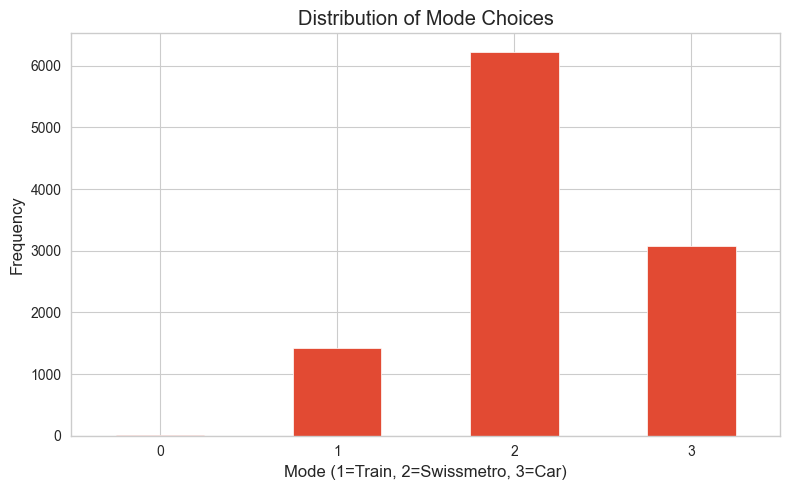

In [18]:
# Check choice distribution
print("\nChoice distribution:")
choice_counts = data['CHOICE'].value_counts().sort_index()
print(choice_counts)

# Plot choice distribution
plt.figure(figsize=(8, 5))
choice_counts.plot(kind='bar')
plt.title('Distribution of Mode Choices')
plt.xlabel('Mode (1=Train, 2=Swissmetro, 3=Car)')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Benchmarking Pre-defined Models

Now we'll compare the performance of different model types (MNL, NL, Mixed Logit) on the Swissmetro dataset.

In [19]:
# Initialize the benchmarker
benchmarker = ModelBenchmarker()

# List of model classes to benchmark
models_to_benchmark = [
    MultinomialLogitModel_SM,
    NestedLogitModel_SM,
    MixedLogitModel_SM
]

# Run benchmark with all models
benchmark_results = benchmarker.run_benchmark(
    data=data,
    models=models_to_benchmark,
    dataset_name="swissmetro"
)


Estimating MultinomialLogitModel_SM...

Before encoding:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

Before filtering:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

After filtering:
Purpose values: PURPOSE
3    5193
1    1575
Name: count, dtype: int64
Choice values: CHOICE
2    4090
3    1770
1     908
Name: count, dtype: int64
Train availability: TRAIN_AV
1    6768
Name: count, dtype: int64
Car availability: CAR_AV
1    5607
0    1161
Name: count, dtype: int64
SM availability: SM_AV
1    6768
Name: count, dtype: int64


DEBUG:biogeme.parameters:READ FILE biogeme.toml : automatic
DEBUG:biogeme.parameters:Parameter file: /Users/carlosguirado/Desktop/Jan25_Dump/mode-choice-benchmarking-sandbox/examples/biogeme.toml
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
INFO:biogeme.parameters:Biogeme parameters read from biogeme.toml.
Obsolete syntax. Use generate_pickle instead of generatePickle 
Obsolete synt

THESE ARE THE BETAS:
{'ASC_CAR': np.float64(-0.15463267198926228), 'ASC_TRAIN': np.float64(-0.7011872849436396), 'B_COST': np.float64(-1.0837900371207707), 'B_TIME': np.float64(-1.277858956519672)}


The chosen alternative [`3.0`] is not available for the following observations (rownumber[choice]): 9[3.0]-10[3.0]-11[3.0]-12[3.0]-13[3.0]-14[3.0]-15[3.0]-16[3.0]-17[3.0]-36[3.0]-37[3.0]-38[3.0]-39[3.... 
The chosen alternative [`3.0`] is not available for the following observations (rownumber[choice]): 9[3.0]-10[3.0]-11[3.0]-12[3.0]-13[3.0]-14[3.0]-15[3.0]-16[3.0]-17[3.0]-36[3.0]-37[3.0]-38[3.0]-39[3.... 
The chosen alternative [`3.0`] is not available for the following observations (rownumber[choice]): 9[3.0]-10[3.0]-11[3.0]-12[3.0]-13[3.0]-14[3.0]-15[3.0]-16[3.0]-17[3.0]-36[3.0]-37[3.0]-38[3.0]-39[3.... 
The chosen alternative [`3.0`] is not available for the following observations (rownumber[choice]): 9[3.0]-10[3.0]-11[3.0]-12[3.0]-13[3.0]-14[3.0]-15[3.0]-16[3.0]-17[3.0]-36[3.0]-37[3.0]-38[3.0]-39[3.... 
The chosen alternative [`3.0`] is not available for the following observations (rownumber[choice]): 9[3.0]-10[3.0]-11[3.0]-12[3.0]-13[3.0]-14[3.0]-15[3.0]-16[3.0]-17[3.0]-36[3.0]-3


Market Shares:
Mode      Actual    Predicted
------------------------------
   1     0.134     0.134
   2     0.604     0.604
   3     0.262     0.262

Market Share Accuracy: 1.000

Confusion Matrix:
Predicted  1     2    3
Actual                 
1          5   848   55
2          1  3762  327
3          0   959  811

Choice Prediction Accuracy: 0.676

Estimating NestedLogitModel_SM...

Before encoding:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

Before filtering:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

After filtering:
Purpose values: PURPOSE
3    5193
1    1575
Name: count, dtype: int64
Choice values: CHOICE
2    4

The following elements do not appear in any nest and are assumed each to be alone in a separate nest: {2}. If it is not the intention, check the assignment of alternatives to nests. 
The following elements do not appear in any nest and are assumed each to be alone in a separate nest: {2}. If it is not the intention, check the assignment of alternatives to nests. 
The following elements do not appear in any nest and are assumed each to be alone in a separate nest: {2}. If it is not the intention, check the assignment of alternatives to nests. 
The following elements do not appear in any nest and are assumed each to be alone in a separate nest: {2}. If it is not the intention, check the assignment of alternatives to nests. 
The following elements do not appear in any nest and are assumed each to be alone in a separate nest: {2}. If it is not the intention, check the assignment of alternatives to nests. 
The following elements do not appear in any nest and are assumed each to be alone in 


Market Shares:
Mode      Actual    Predicted
------------------------------
   1     0.134     0.224
   2     0.604     0.473
   3     0.262     0.303

Market Share Accuracy: 0.869

Confusion Matrix:
Predicted    1     2     3
Actual                    
1           22   632   254
2          304  2640  1146
3           35  1594   141

Choice Prediction Accuracy: 0.414

Estimating MixedLogitModel_SM...

Before encoding:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

Before filtering:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

After filtering:
Purpose values: PURPOSE
3    5193
1    1575
Name: count, dtype: int64
Choice values:

Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
INFO:biogeme.parameters:Biogeme parameters read from biogeme.toml.
Obsolete syntax. Use generate_pickle instead of generatePickle 
Obsolete syntax. Use generate_pickle instead of generatePickle 
Obsolete syntax. Use generate_pickle instead of generateP


Market Shares:
Mode      Actual    Predicted
------------------------------
   1     0.134     0.104
   2     0.604     0.640
   3     0.262     0.256

Market Share Accuracy: 0.964

Confusion Matrix:
Predicted  1     2    3
Actual                 
1          6   819   83
2          2  3681  407
3          0   883  887

Choice Prediction Accuracy: 0.676


/Users/carlosguirado/Desktop/Jan25_Dump/mode-choice-benchmarking-sandbox/mcbs/models/swissmetro_model.py:223: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prob_max = prob_max.replace({'Prob. train': 1, 'Prob. SM': 2, 'Prob. car': 3})


In [20]:
# Print the comparison results
benchmarker.print_comparison()


Model Comparison Results:
              model_name   final_ll  rho_squared_bar  market_share_accuracy  choice_accuracy      vot  n_parameters  n_observations
      MixedLogitModel_SM -5216.3405           0.2503                 0.9643           0.6758 104.1935             5            6768
     NestedLogitModel_SM -5236.9003           0.2474                 0.8685           0.4142  62.9559             5            6768
MultinomialLogitModel_SM -5331.2520           0.2340                 1.0000           0.6764  70.7439             4            6768

Best performing model (by rho squared bar): MixedLogitModel_SM


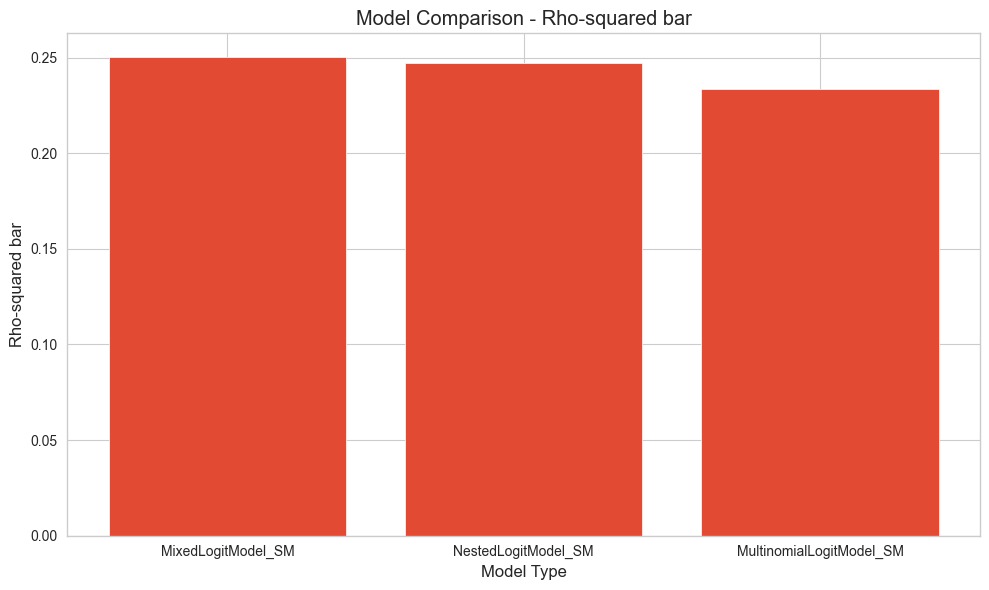

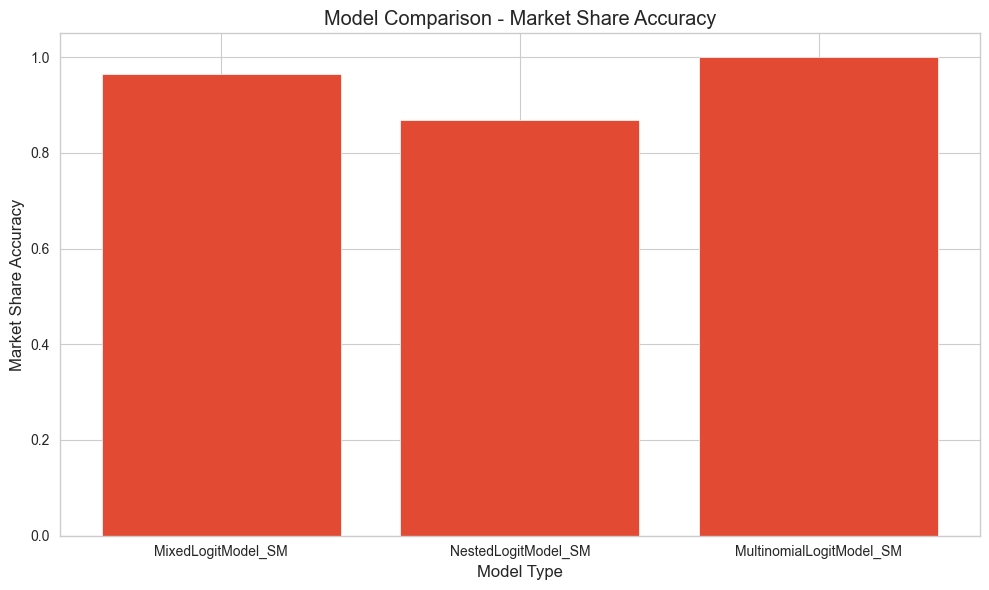

In [21]:
# Plot the comparison metrics
metrics = benchmark_results.reset_index()

# Plot rho-squared bar (goodness of fit)
plt.figure(figsize=(10, 6))
plt.bar(metrics['model_name'], metrics['rho_squared_bar'])
plt.title('Model Comparison - Rho-squared bar')
plt.xlabel('Model Type')
plt.ylabel('Rho-squared bar')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot market share accuracy
plt.figure(figsize=(10, 6))
plt.bar(metrics['model_name'], metrics['market_share_accuracy'])
plt.title('Model Comparison - Market Share Accuracy')
plt.xlabel('Model Type')
plt.ylabel('Market Share Accuracy')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Creating a Custom Model

Let's create and benchmark a custom model with a different utility specification. This will be a modified MNL model with seat availability as an additional variable for Swissmetro.

In [22]:
class CustomMNLModel(BaseSwissmetroModel):
    """Custom MNL model with additional seat availability coefficient for Swissmetro."""
    
    def estimate(self):
        """Estimate the custom MNL model."""
        # Parameters to be estimated
        ASC_CAR = Beta('ASC_CAR', 0, None, None, 0)
        ASC_TRAIN = Beta('ASC_TRAIN', 0, None, None, 0)
        ASC_SM = Beta('ASC_SM', 0, None, None, 1)  # Fixed parameter
        B_TIME = Beta('B_TIME', 0, None, None, 0)
        B_COST = Beta('B_COST', 0, None, None, 0)
        B_SEATS = Beta('B_SEATS', 0, None, None, 0)  # Added parameter for seat availability

        # Definition of the utility functions
        V1 = ASC_TRAIN + B_TIME * self.TRAIN_TT_SCALED + B_COST * self.TRAIN_COST_SCALED
        V2 = ASC_SM + B_TIME * self.SM_TT_SCALED + B_COST * self.SM_COST_SCALED + B_SEATS * self.SM_SEATS
        V3 = ASC_CAR + B_TIME * self.CAR_TT_SCALED + B_COST * self.CAR_CO_SCALED

        # Associate utility functions with alternatives
        V = {1: V1, 2: V2, 3: V3}

        # Associate availability conditions
        av = {1: self.TRAIN_AV_SP, 2: self.SM_AV, 3: self.CAR_AV_SP}

        # Define and estimate the model
        logprob = models.loglogit(V, av, self.CHOICE)
        biogeme = bio.BIOGEME(self.database, logprob)
        biogeme.modelName = "custom_mnl_model"
        
        # Disable HTML and Pickle generation
        biogeme.generateHtml = False
        biogeme.generatePickle = False
        
        # Calculate null log likelihood and estimate
        biogeme.calculate_null_loglikelihood(av)
        self.results = biogeme.estimate()
        
        # Get general statistics
        stats = self.results.getGeneralStatistics()
        
        # Store statistics
        self.final_ll = stats['Final log likelihood'][0]
        self.rho_squared = stats['Rho-square for the null model'][0]
        self.rho_squared_bar = stats['Rho-square-bar for the null model'][0]
        
        # Calculate value of time (in CHF/hour)
        betas = self.results.get_beta_values()
        self.vot = 60 * betas['B_TIME'] / betas['B_COST'] if 'B_COST' in betas else None
        
        # Calculate market shares and accuracies
        self.calculate_choice_accuracy()
        
        return self.results
    
    def _get_utility_function(self, alternative):
        """Get utility function for a specific alternative."""
        betas = self.results.get_beta_values()
        if alternative == 1:  # Train
            return (betas['ASC_TRAIN'] + 
                   betas['B_TIME'] * self.TRAIN_TT_SCALED + 
                   betas['B_COST'] * self.TRAIN_COST_SCALED)
        elif alternative == 2:  # Swissmetro
            return (betas['B_TIME'] * self.SM_TT_SCALED + 
                   betas['B_COST'] * self.SM_COST_SCALED + 
                   betas['B_SEATS'] * self.SM_SEATS)
        elif alternative == 3:  # Car
            return (betas['ASC_CAR'] + 
                   betas['B_TIME'] * self.CAR_TT_SCALED + 
                   betas['B_COST'] * self.CAR_CO_SCALED)
        else:
            raise ValueError(f"Invalid alternative: {alternative}")

In [23]:
# Benchmark the custom model against the standard MNL model
new_benchmarker = ModelBenchmarker()
benchmark_results = new_benchmarker.run_benchmark(
    data=data,
    models=[MultinomialLogitModel_SM, CustomMNLModel],
    dataset_name="swissmetro"
)

# Print comparison results
new_benchmarker.print_comparison()


Estimating MultinomialLogitModel_SM...

Before encoding:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

Before filtering:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

After filtering:
Purpose values: PURPOSE
3    5193
1    1575
Name: count, dtype: int64
Choice values: CHOICE
2    4090
3    1770
1     908
Name: count, dtype: int64
Train availability: TRAIN_AV
1    6768
Name: count, dtype: int64
Car availability: CAR_AV
1    5607
0    1161
Name: count, dtype: int64
SM availability: SM_AV
1    6768
Name: count, dtype: int64


DEBUG:biogeme.parameters:READ FILE biogeme.toml : automatic
DEBUG:biogeme.parameters:Parameter file: /Users/carlosguirado/Desktop/Jan25_Dump/mode-choice-benchmarking-sandbox/examples/biogeme.toml
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
INFO:biogeme

THESE ARE THE BETAS:
{'ASC_CAR': np.float64(-0.15463267198926228), 'ASC_TRAIN': np.float64(-0.7011872849436396), 'B_COST': np.float64(-1.0837900371207707), 'B_TIME': np.float64(-1.277858956519672)}


The chosen alternative [`3.0`] is not available for the following observations (rownumber[choice]): 9[3.0]-10[3.0]-11[3.0]-12[3.0]-13[3.0]-14[3.0]-15[3.0]-16[3.0]-17[3.0]-36[3.0]-37[3.0]-38[3.0]-39[3.... 
The chosen alternative [`3.0`] is not available for the following observations (rownumber[choice]): 9[3.0]-10[3.0]-11[3.0]-12[3.0]-13[3.0]-14[3.0]-15[3.0]-16[3.0]-17[3.0]-36[3.0]-37[3.0]-38[3.0]-39[3.... 
The chosen alternative [`3.0`] is not available for the following observations (rownumber[choice]): 9[3.0]-10[3.0]-11[3.0]-12[3.0]-13[3.0]-14[3.0]-15[3.0]-16[3.0]-17[3.0]-36[3.0]-37[3.0]-38[3.0]-39[3.... 
The chosen alternative [`3.0`] is not available for the following observations (rownumber[choice]): 9[3.0]-10[3.0]-11[3.0]-12[3.0]-13[3.0]-14[3.0]-15[3.0]-16[3.0]-17[3.0]-36[3.0]-37[3.0]-38[3.0]-39[3.... 
The chosen alternative [`3.0`] is not available for the following observations (rownumber[choice]): 9[3.0]-10[3.0]-11[3.0]-12[3.0]-13[3.0]-14[3.0]-15[3.0]-16[3.0]-17[3.0]-36[3.0]-3


Market Shares:
Mode      Actual    Predicted
------------------------------
   1     0.134     0.134
   2     0.604     0.604
   3     0.262     0.262

Market Share Accuracy: 1.000

Confusion Matrix:
Predicted  1     2    3
Actual                 
1          5   848   55
2          1  3762  327
3          0   959  811

Choice Prediction Accuracy: 0.676

Estimating CustomMNLModel...

Before encoding:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

Before filtering:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

After filtering:
Purpose values: PURPOSE
3    5193
1    1575
Name: count, dtype: int64
Choice values: CHOICE
2    4090
3

Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
INFO:biogeme.parameters:Biogeme parameters read from biogeme.toml.
Obsolete syntax. Use generate_pickle instead of generatePickle 
Obsolete syntax. Use generate_pic


Market Shares:
Mode      Actual    Predicted
------------------------------
   1     0.134     0.134
   2     0.604     0.604
   3     0.262     0.262

Market Share Accuracy: 1.000

Confusion Matrix:
Predicted  1     2    3
Actual                 
1          6   838   64
2          2  3741  347
3          0   988  782

Choice Prediction Accuracy: 0.669

Model Comparison Results:
              model_name   final_ll  rho_squared_bar  market_share_accuracy  choice_accuracy     vot  n_parameters  n_observations
          CustomMNLModel -5321.9457           0.2351                    1.0           0.6692     NaN             5            6768
MultinomialLogitModel_SM -5331.2520           0.2340                    1.0           0.6764 70.7439             4            6768

Best performing model (by rho squared bar): CustomMNLModel


/Users/carlosguirado/Desktop/Jan25_Dump/mode-choice-benchmarking-sandbox/mcbs/models/swissmetro_model.py:223: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prob_max = prob_max.replace({'Prob. train': 1, 'Prob. SM': 2, 'Prob. car': 3})


## 5. Sensitivity Analysis

Let's perform a sensitivity analysis to see how changes in travel costs affect mode choice probabilities.

In [24]:
def modify_dataset(data, mode, variable, change):
    """Create a modified version of the dataset."""
    modified_data = data.copy()
    
    # Apply modification to the specified variable for the specified mode
    if mode == 1:  # Train
        if variable == 'cost':
            modified_data['TRAIN_CO'] *= (1 + change)
        elif variable == 'time':
            modified_data['TRAIN_TT'] *= (1 + change)
    elif mode == 2:  # Swissmetro
        if variable == 'cost':
            modified_data['SM_CO'] *= (1 + change)
        elif variable == 'time':
            modified_data['SM_TT'] *= (1 + change)
    elif mode == 3:  # Car
        if variable == 'cost':
            modified_data['CAR_CO'] *= (1 + change)
        elif variable == 'time':
            modified_data['CAR_TT'] *= (1 + change)
    
    return modified_data

In [25]:
# Estimate base model that we'll use for sensitivity analysis
base_model = MultinomialLogitModel_SM(data)
base_model.estimate()

# Create a range of cost multipliers for sensitivity analysis
changes = [-0.5, -0.25, 0, 0.25, 0.5, 0.75, 1.0]
mode_to_analyze = 2  # Swissmetro
variable = 'cost'

# Collect market shares for each scenario
scenarios = []
for change in changes:
    # Modify the dataset
    modified_data = modify_dataset(data, mode_to_analyze, variable, change)
    
    # Create a new model instance for simulation
    sim_model = MultinomialLogitModel_SM(modified_data)
    sim_model.results = base_model.results
    sim_model.calculate_choice_accuracy()
    
    # Store the results
    scenarios.append({
        'change': change,
        'multiplier': 1 + change,  # For plotting
        'shares': sim_model.predicted_shares
    })


Before encoding:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

Before filtering:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

After filtering:
Purpose values: PURPOSE
3    5193
1    1575
Name: count, dtype: int64
Choice values: CHOICE
2    4090
3    1770
1     908
Name: count, dtype: int64
Train availability: TRAIN_AV
1    6768
Name: count, dtype: int64
Car availability: CAR_AV
1    5607
0    1161
Name: count, dtype: int64
SM availability: SM_AV
1    6768
Name: count, dtype: int64


DEBUG:biogeme.parameters:READ FILE biogeme.toml : automatic
DEBUG:biogeme.parameters:Parameter file: /Users/carlosguirado/Desktop/Jan25_Dump/mode-choice-benchmarking-sandbox/examples/biogeme.toml
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme para

THESE ARE THE BETAS:
{'ASC_CAR': np.float64(-0.15463267198926228), 'ASC_TRAIN': np.float64(-0.7011872849436396), 'B_COST': np.float64(-1.0837900371207707), 'B_TIME': np.float64(-1.277858956519672)}


The chosen alternative [`3.0`] is not available for the following observations (rownumber[choice]): 9[3.0]-10[3.0]-11[3.0]-12[3.0]-13[3.0]-14[3.0]-15[3.0]-16[3.0]-17[3.0]-36[3.0]-37[3.0]-38[3.0]-39[3.... 
The chosen alternative [`3.0`] is not available for the following observations (rownumber[choice]): 9[3.0]-10[3.0]-11[3.0]-12[3.0]-13[3.0]-14[3.0]-15[3.0]-16[3.0]-17[3.0]-36[3.0]-37[3.0]-38[3.0]-39[3.... 
The chosen alternative [`3.0`] is not available for the following observations (rownumber[choice]): 9[3.0]-10[3.0]-11[3.0]-12[3.0]-13[3.0]-14[3.0]-15[3.0]-16[3.0]-17[3.0]-36[3.0]-37[3.0]-38[3.0]-39[3.... 
The chosen alternative [`3.0`] is not available for the following observations (rownumber[choice]): 9[3.0]-10[3.0]-11[3.0]-12[3.0]-13[3.0]-14[3.0]-15[3.0]-16[3.0]-17[3.0]-36[3.0]-37[3.0]-38[3.0]-39[3.... 
The chosen alternative [`3.0`] is not available for the following observations (rownumber[choice]): 9[3.0]-10[3.0]-11[3.0]-12[3.0]-13[3.0]-14[3.0]-15[3.0]-16[3.0]-17[3.0]-36[3.0]-3


Market Shares:
Mode      Actual    Predicted
------------------------------
   1     0.134     0.134
   2     0.604     0.604
   3     0.262     0.262

Market Share Accuracy: 1.000

Confusion Matrix:
Predicted  1     2    3
Actual                 
1          5   848   55
2          1  3762  327
3          0   959  811

Choice Prediction Accuracy: 0.676

Before encoding:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

Before filtering:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

After filtering:
Purpose values: PURPOSE
3    5193
1    1575
Name: count, dtype: int64
Choice values: CHOICE
2    4090
3    1770
1     908
Name: count

...

Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from bio


Market Shares:
Mode      Actual    Predicted
------------------------------
   1     0.134     0.191
   2     0.604     0.444
   3     0.262     0.366

Market Share Accuracy: 0.839

Confusion Matrix:
Predicted   1     2     3
Actual                   
1          28   723   157
2          73  2677  1340
3           0   331  1439

Choice Prediction Accuracy: 0.612

Before encoding:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

Before filtering:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

After filtering:
Purpose values: PURPOSE
3    5193
1    1575
Name: count, dtype: int64
Choice values: CHOICE
2    4090
3    1770
1     908
N

Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from bio


Market Shares:
Mode      Actual    Predicted
------------------------------
   1     0.134     0.208
   2     0.604     0.399
   3     0.262     0.393

Market Share Accuracy: 0.795

Confusion Matrix:
Predicted    1     2     3
Actual                    
1           46   686   176
2          128  2273  1689
3            2   213  1555

Choice Prediction Accuracy: 0.572


/Users/carlosguirado/Desktop/Jan25_Dump/mode-choice-benchmarking-sandbox/mcbs/models/swissmetro_model.py:223: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prob_max = prob_max.replace({'Prob. train': 1, 'Prob. SM': 2, 'Prob. car': 3})


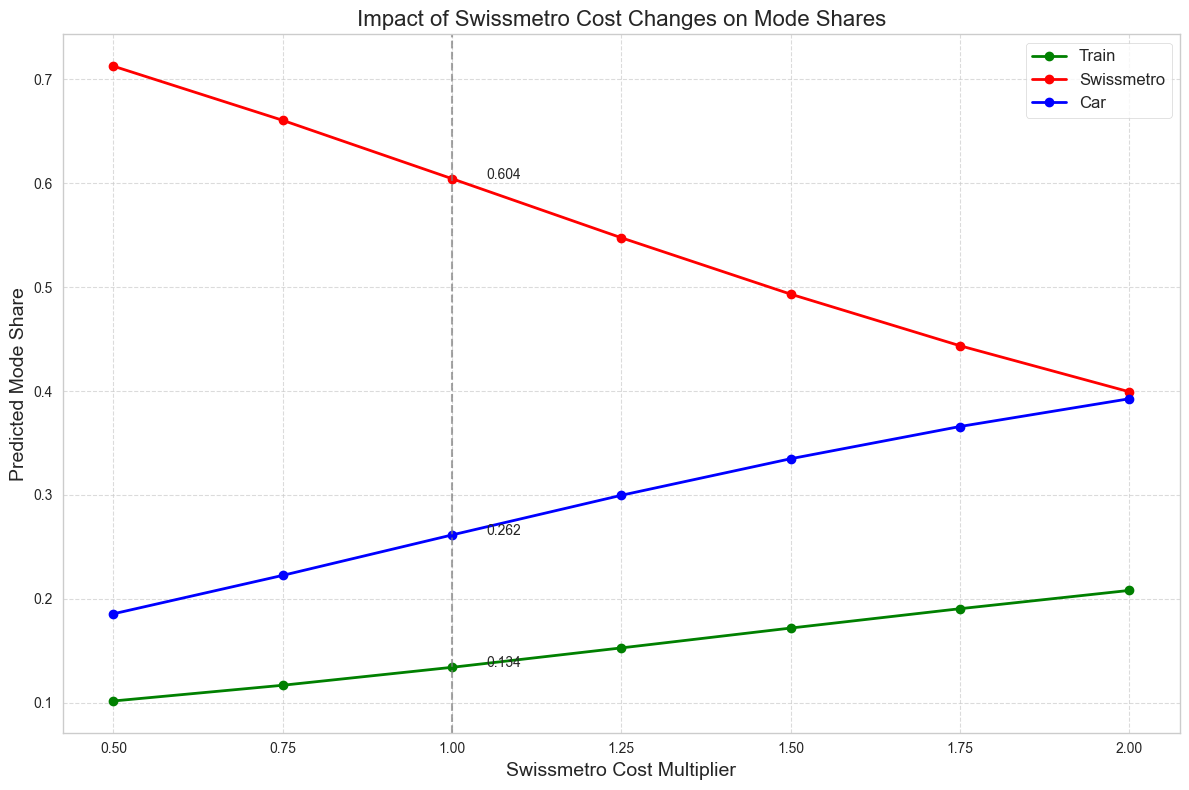

In [26]:
# Plot the results
plt.figure(figsize=(12, 8))

# Plot evolution for each mode
mode_names = {1: 'Train', 2: 'Swissmetro', 3: 'Car'}
colors = {1: 'green', 2: 'red', 3: 'blue'}

for mode_num in [1, 2, 3]:
    shares = [scenario['shares'][mode_num] for scenario in scenarios]
    multipliers = [scenario['multiplier'] for scenario in scenarios]
    
    plt.plot(multipliers, shares, marker='o', label=mode_names[mode_num], color=colors[mode_num], linewidth=2)

# Customize plot
plt.title(f'Impact of Swissmetro Cost Changes on Mode Shares', fontsize=16)
plt.xlabel('Swissmetro Cost Multiplier', fontsize=14)
plt.ylabel('Predicted Mode Share', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.xticks(multipliers)
plt.axvline(x=1.0, color='gray', linestyle='--', alpha=0.7)  # vertical line at baseline

# Add annotations for key points
baseline_idx = changes.index(0)
for mode_num in [1, 2, 3]:
    baseline_share = scenarios[baseline_idx]['shares'][mode_num]
    plt.annotate(f'{baseline_share:.3f}', 
                 xy=(1.0, baseline_share),
                 xytext=(1.05, baseline_share),
                 fontsize=10)

plt.tight_layout()
plt.show()

## 6. Cross-Elasticity Analysis

Let's calculate elasticities to quantify how responsive the demand for each mode is to changes in cost.

In [27]:
# Calculate point elasticities
baseline_idx = changes.index(0)
baseline_scenario = scenarios[baseline_idx]

# Calculate elasticities for a small change (e.g., +10%)
change_idx = changes.index(0.1) if 0.1 in changes else None
if change_idx is None:
    # If we don't have exactly +10%, add it to our scenarios
    modified_data = modify_dataset(data, mode_to_analyze, variable, 0.1)
    sim_model = MultinomialLogitModel_SM(modified_data)
    sim_model.results = base_model.results
    sim_model.calculate_choice_accuracy()
    change_scenario = {
        'change': 0.1,
        'multiplier': 1.1,
        'shares': sim_model.predicted_shares
    }
else:
    change_scenario = scenarios[change_idx]

# Calculate elasticities for each mode
elasticities = {}
for mode_num in [1, 2, 3]:
    # Percent change in share / percent change in price
    pct_change_share = (change_scenario['shares'][mode_num] - baseline_scenario['shares'][mode_num]) / baseline_scenario['shares'][mode_num]
    pct_change_price = 0.1  # 10% increase
    elasticity = pct_change_share / pct_change_price
    elasticities[mode_num] = elasticity

# Display elasticities
print(f"Elasticities for a 10% increase in Swissmetro cost:")
for mode_num, elasticity in elasticities.items():
    if mode_num == mode_to_analyze:
        print(f"{mode_names[mode_num]} (direct elasticity): {elasticity:.2f}")
    else:
        print(f"{mode_names[mode_num]} (cross elasticity): {elasticity:.2f}")


Before encoding:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

Before filtering:
Purpose values: PURPOSE
3    5193
4    2304
1    1575
2    1278
5     144
7     144
6      63
9      18
8       9
Name: count, dtype: int64
Choice values: CHOICE
2    6216
3    3080
1    1423
0       9
Name: count, dtype: int64

After filtering:
Purpose values: PURPOSE
3    5193
1    1575
Name: count, dtype: int64
Choice values: CHOICE
2    4090
3    1770
1     908
Name: count, dtype: int64
Train availability: TRAIN_AV
1    6768
Name: count, dtype: int64
Car availability: CAR_AV
1    5607
0    1161
Name: count, dtype: int64
SM availability: SM_AV
1    6768
Name: count, dtype: int64


DEBUG:biogeme.parameters:READ FILE biogeme.toml : automatic
DEBUG:biogeme.parameters:Parameter file: /Users/carlosguirado/Desktop/Jan25_Dump/mode-choice-benchmarking-sandbox/examples/biogeme.toml
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme parameters read from biogeme.toml. 
Biogeme para


Market Shares:
Mode      Actual    Predicted
------------------------------
   1     0.134     0.142
   2     0.604     0.581
   3     0.262     0.277

Market Share Accuracy: 0.977

Confusion Matrix:
Predicted  1     2    3
Actual                 
1          6   833   69
2          5  3660  425
3          0   849  921

Choice Prediction Accuracy: 0.678
Elasticities for a 10% increase in Swissmetro cost:
Train (cross elasticity): 0.55
Swissmetro (direct elasticity): -0.38
Car (cross elasticity): 0.59


/Users/carlosguirado/Desktop/Jan25_Dump/mode-choice-benchmarking-sandbox/mcbs/models/swissmetro_model.py:223: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prob_max = prob_max.replace({'Prob. train': 1, 'Prob. SM': 2, 'Prob. car': 3})


## 7. Conclusion

In this tutorial, we've demonstrated how to:
1. Load transportation choice datasets using fetch_data
2. Use the ModelBenchmarker to compare different model types
3. Create a custom model with additional parameters
4. Perform sensitivity analysis to understand how changes in attributes affect mode choices
5. Calculate elasticities to quantify mode choice responsiveness

The MCBS framework provides a systematic way to compare discrete choice models and understand their performance on transportation datasets.